In [1]:
print("--- Part 1: Importing Necessary Libraries and Dataset ---")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass

# Load dataset
try:
    df = pd.read_csv('MicrosoftStock.csv')
    print("Dataset loaded.")
except FileNotFoundError:
    print("Error: MicrosoftStock.csv not found.")
    exit()

print("\n--- Dataset Head ---")
print(df.head())

print("\n--- Dataset Info ---")
df.info()

print("\n--- Dataset Description ---")
print(df.describe())

print(f"\nUnique dates: {df['date'].nunique()}")
print(f"Total rows: {len(df)}")


--- Part 1: Importing Necessary Libraries and Dataset ---
Dataset loaded.

--- Dataset Head ---
    index        date   open   high    low  close    volume  Name
0  390198  2013-02-08  27.35  27.71  27.31  27.55  33318306  MSFT
1  390199  2013-02-11  27.65  27.92  27.50  27.86  32247549  MSFT
2  390200  2013-02-12  27.88  28.00  27.75  27.88  35990829  MSFT
3  390201  2013-02-13  27.93  28.11  27.88  28.03  41715530  MSFT
4  390202  2013-02-14  27.92  28.06  27.87  28.04  32663174  MSFT

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   index   1259 non-null   int64  
 1   date    1259 non-null   object 
 2   open    1259 non-null   float64
 3   high    1259 non-null   float64
 4   low     1259 non-null   float64
 5   close   1259 non-null   float64
 6   volume  1259 non-null   int64  
 7   Name    1259 non-null   object 
dtypes: fl

In [3]:
print("\n--- Part 2: Data Preprocessing ---")

df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

df.drop(columns=['index', 'Name'], inplace=True, errors='ignore')

numerical_cols = df.select_dtypes(include=np.number).columns
if df[numerical_cols].isnull().sum().sum() > 0:
    df[numerical_cols] = df[numerical_cols].interpolate(method='linear')

print(df.isnull().sum())



--- Part 2: Data Preprocessing ---
open      0
high      0
low       0
close     0
volume    0
dtype: int64


In [5]:
print("\nCreating technical indicators...")

df['SMA_20'] = df['close'].rolling(20).mean()
df['EMA_20'] = df['close'].ewm(span=20, adjust=False).mean()

df['Middle_Band'] = df['SMA_20']
df['Upper_Band'] = df['Middle_Band'] + df['close'].rolling(20).std() * 2
df['Lower_Band'] = df['Middle_Band'] - df['close'].rolling(20).std() * 2

def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = delta.where(delta > 0, 0)
    loss = (-delta).where(delta < 0, 0)
    avg_gain = gain.ewm(com=window-1, min_periods=window).mean()
    avg_loss = loss.ewm(com=window-1, min_periods=window).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

df['RSI'] = calculate_rsi(df['close'])

df.dropna(inplace=True)
df.info()



Creating technical indicators...
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1240 entries, 2013-03-08 to 2018-02-07
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   open         1240 non-null   float64
 1   high         1240 non-null   float64
 2   low          1240 non-null   float64
 3   close        1240 non-null   float64
 4   volume       1240 non-null   int64  
 5   SMA_20       1240 non-null   float64
 6   EMA_20       1240 non-null   float64
 7   Middle_Band  1240 non-null   float64
 8   Upper_Band   1240 non-null   float64
 9   Lower_Band   1240 non-null   float64
 10  RSI          1240 non-null   float64
dtypes: float64(10), int64(1)
memory usage: 116.2 KB


In [7]:
features_to_scale = [
    'open','high','low','close','volume',
    'SMA_20','EMA_20','Middle_Band','Upper_Band','Lower_Band','RSI'
]

scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df[features_to_scale])
df_scaled = pd.DataFrame(df_scaled, columns=features_to_scale, index=df.index)

train_size = int(len(df_scaled) * 0.8)
train_data = df_scaled.iloc[:train_size]
test_data = df_scaled.iloc[train_size:]


In [9]:
LOOK_BACK = 60

def create_sequences(dataset, look_back=LOOK_BACK):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:i+look_back])
        Y.append(dataset[i+look_back, df_scaled.columns.get_loc('close')])
    return np.array(X), np.array(Y)

train_array = train_data.values
test_array = test_data.values

X_train, y_train = create_sequences(train_array)
X_test, y_test = create_sequences(test_array)

y_test_reshaped = y_test.reshape(-1, 1)



--- Part 3: Exploratory Data Analysis ---


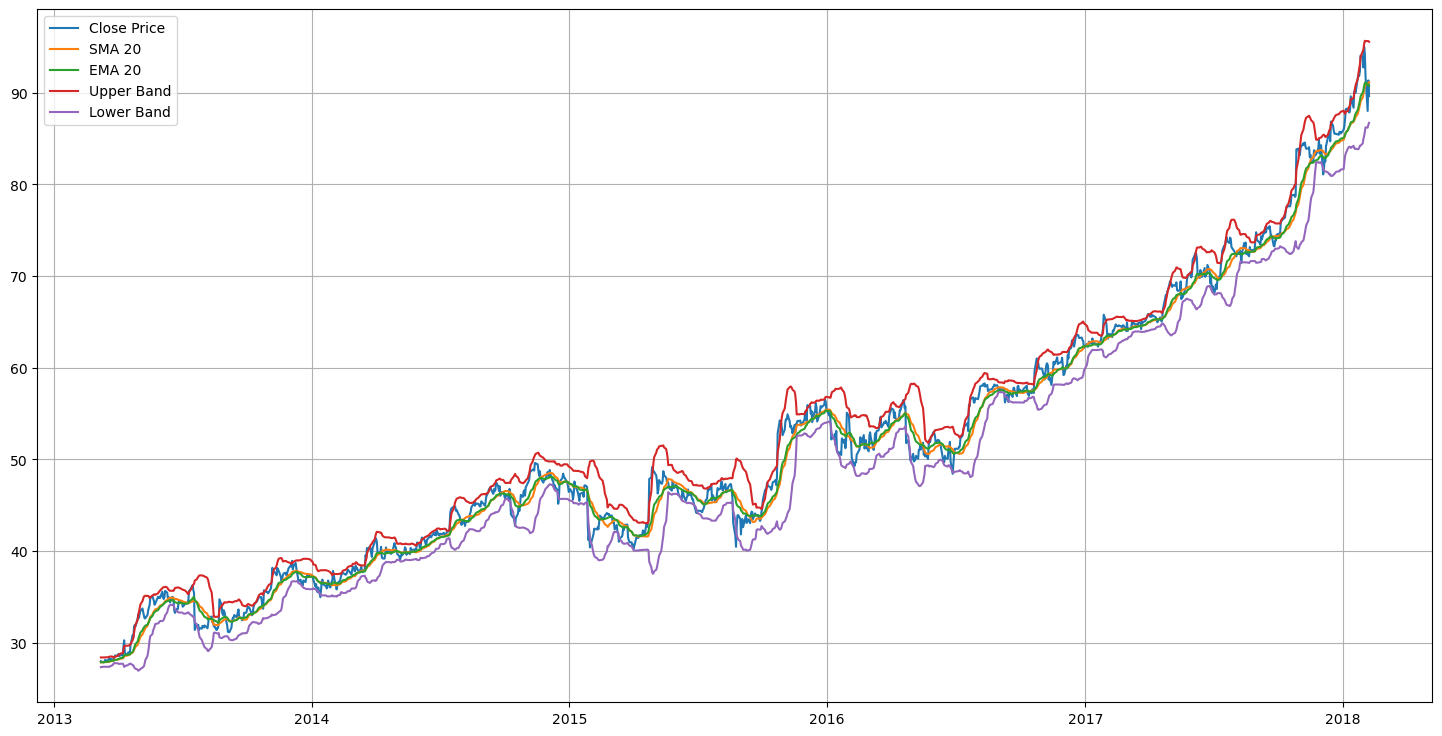

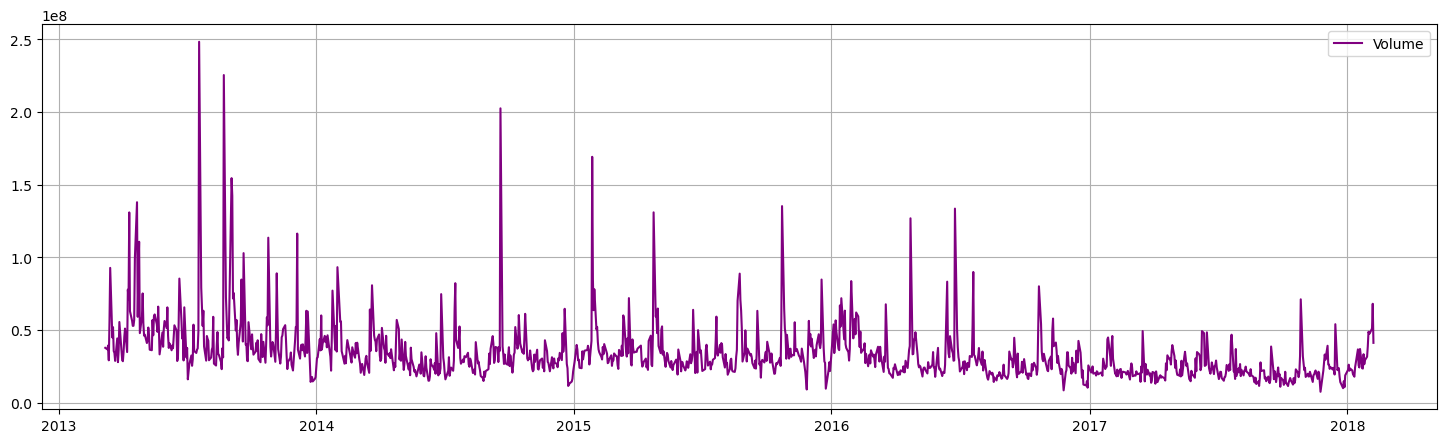

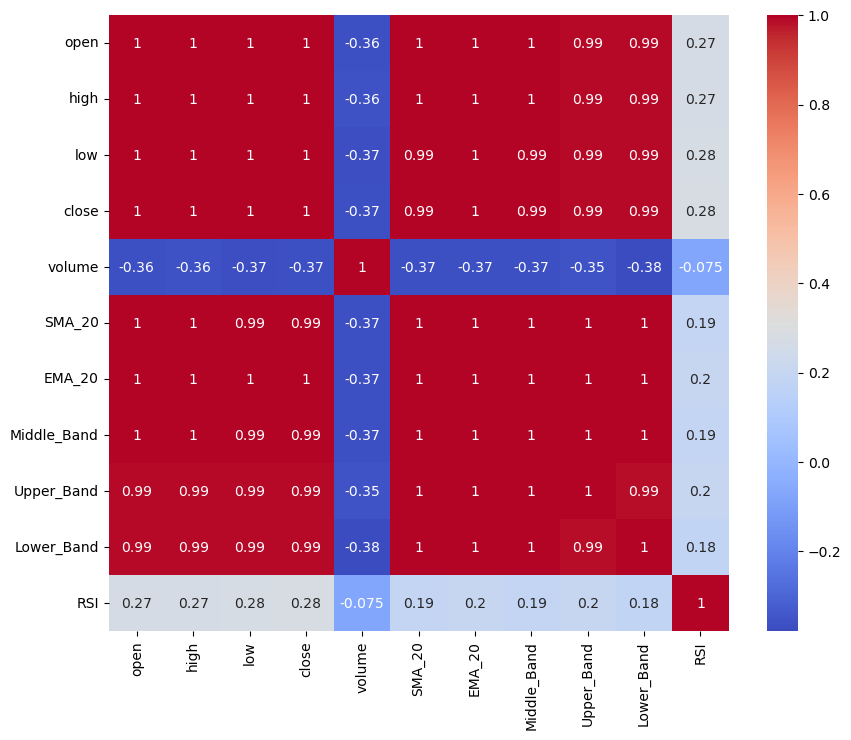

close          1.000000
low            0.999677
high           0.999657
open           0.999321
EMA_20         0.996335
SMA_20         0.994908
Middle_Band    0.994908
Upper_Band     0.993595
Lower_Band     0.989382
RSI            0.278712
volume        -0.365648
Name: close, dtype: float64


In [11]:
print("\n--- Part 3: Exploratory Data Analysis ---")

plt.figure(figsize=(18,9))
plt.plot(df['close'], label='Close Price')
plt.plot(df['SMA_20'], label='SMA 20')
plt.plot(df['EMA_20'], label='EMA 20')
plt.plot(df['Upper_Band'], label='Upper Band')
plt.plot(df['Lower_Band'], label='Lower Band')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(18,5))
plt.plot(df['volume'], label='Volume', color='purple')
plt.legend()
plt.grid()
plt.show()

corr = df[features_to_scale].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

print(corr['close'].sort_values(ascending=False))



--- Part 4: Model Training ---


C:\Users\vamsh\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 106ms/step - loss: 0.0110 - val_loss: 0.0061
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - loss: 0.0025 - val_loss: 6.6507e-04
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 0.0020 - val_loss: 4.8087e-04
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 0.0017 - val_loss: 0.0011
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - loss: 0.0014 - val_loss: 8.1919e-04
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - loss: 0.0013 - val_loss: 0.0019
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - loss: 0.0011 - val_loss: 7.2713e-04
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - loss: 0.0011 - val_loss: 3.3894e-04
Epoch 10/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 0.0011 - val_loss: 2.7821e-04
Epoch 11/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 0.0012 - val_loss: 7.4918e-04
Epoch 12/100
27/27 ━━━━

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 50)              │          12,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 60, 50)              │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 158,555 (619.36 KB)

 Trainable params: 52,851 (206.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 105,704 (412.91 KB)

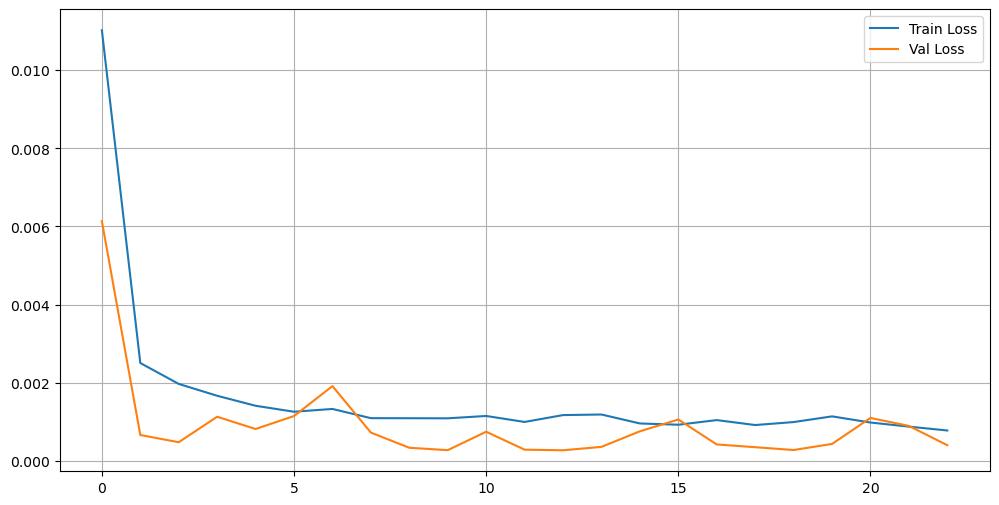

In [13]:
print("\n--- Part 4: Model Training ---")

model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),

    LSTM(50, return_sequences=True),
    Dropout(0.2),

    LSTM(50),
    Dropout(0.2),

    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

model.summary()

plt.figure(figsize=(12,6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.grid()
plt.show()


In [15]:
print("\n--- Part 5: Model Evaluation & Prediction ---")

y_pred_scaled = model.predict(X_test)

dummy_pred = np.zeros((len(y_pred_scaled), len(features_to_scale)))
dummy_actual = np.zeros((len(y_test_reshaped), len(features_to_scale)))

close_col = features_to_scale.index('close')

dummy_pred[:, close_col] = y_pred_scaled.flatten()
dummy_actual[:, close_col] = y_test_reshaped.flatten()

y_pred = scaler.inverse_transform(dummy_pred)[:, close_col]
y_actual = scaler.inverse_transform(dummy_actual)[:, close_col]

mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
r2 = r2_score(y_actual, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)



--- Part 5: Model Evaluation & Prediction ---
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step
MAE: 3.470881075871746
RMSE: 4.32565691726185
R²: 0.649069285790724


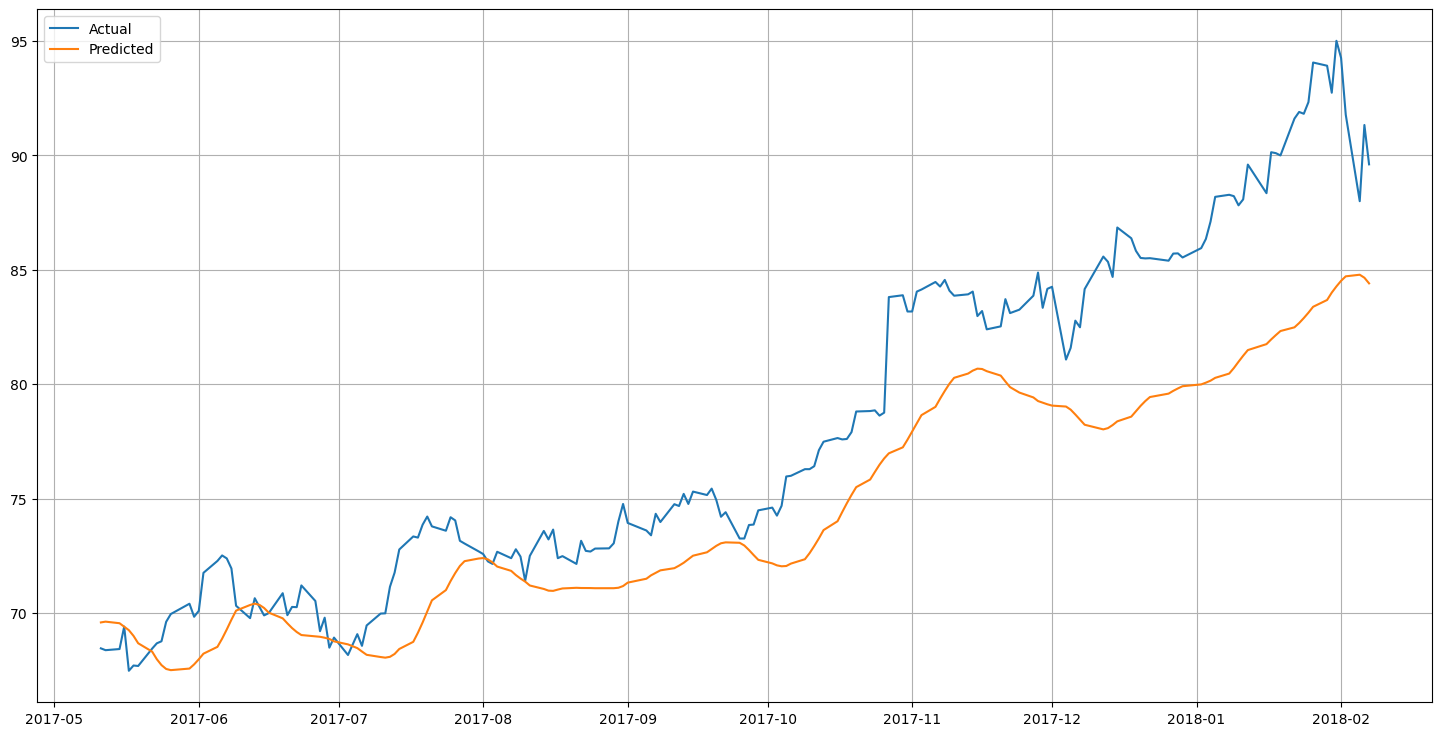

In [16]:
plt.figure(figsize=(18,9))
plt.plot(df.index[train_size+LOOK_BACK:], y_actual, label='Actual')
plt.plot(df.index[train_size+LOOK_BACK:], y_pred, label='Predicted')
plt.legend()
plt.grid()
plt.show()


In [17]:
print("\n--- Future Forecast (30 Days) ---")

last_n_days = df_scaled.iloc[-LOOK_BACK:].values
current_input = last_n_days.reshape(1, LOOK_BACK, len(features_to_scale))

future_preds_scaled = []
future_days = 30

for _ in range(future_days):
    next_pred_scaled = model.predict(current_input)[0][0]
    future_preds_scaled.append(next_pred_scaled)

    new_features = np.zeros((len(features_to_scale),))
    new_features[close_col] = next_pred_scaled

    for i in range(len(features_to_scale)):
        if i != close_col:
            new_features[i] = current_input[0, -1, i]

    current_input = np.append(current_input[:, 1:, :], new_features.reshape(1,1,-1), axis=1)

future_dummy = np.zeros((future_days, len(features_to_scale)))
future_dummy[:, close_col] = np.array(future_preds_scaled)

future_predictions = scaler.inverse_transform(future_dummy)[:, close_col]

future_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=future_days, freq='B')

future_df = pd.DataFrame({'Predicted Close': future_predictions}, index=future_dates)
print(future_df)



--- Future Forecast (30 Days) ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━